# 💼 07 — Business Insights & Action Plan
## Insurance Retention Analytics

> **Objetivo:** Cerrar el ciclo del proyecto convirtiendo el modelo entrenado en **acciones de negocio cuantificables**. Generamos el scoring del portafolio completo, identificamos clientes en riesgo y oportunidades de cross-sell, y producimos los datasets que alimentarán Power BI y SQL Server.

**Fase CRISP-DM:** Deployment (preparación)  
**Autor:** [Tu Nombre]  
**Fecha:** 2026

---

## Tabla de contenidos

1. [Setup y carga](#1-setup)
2. [Scoring del portafolio completo](#2-scoring)
3. [Bucketing por riesgo (4 niveles)](#3-buckets)
4. [Análisis del portafolio en riesgo](#4-risk-portfolio)
5. [Cuantificación económica](#5-economics)
6. [Oportunidad de cross-selling](#6-cross-sell)
7. [Top clientes para acción inmediata](#7-top-clients)
8. [Export para Power BI y SQL Server](#8-export)
9. [KPIs ejecutivos](#9-kpis)
10. [Conclusión](#10-conclusion)

---

<a id="1-setup"></a>
## 1. Setup y carga del modelo

Cargamos el modelo final, el dataset original y los splits necesarios.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

COLORS = {"retained":"#2E86AB", "churn":"#E63946", "accent":"#F4A261",
          "neutral":"#6C757D", "good":"#06A77D",
          "critico":"#9D0208", "alto":"#E63946", "medio":"#F4A261", "bajo":"#06A77D"}
FIG = Path("../reports/figures")
FIG.mkdir(parents=True, exist_ok=True)

In [4]:
# Cargar modelo, features y dataset crudo
modelo         = joblib.load("../models/xgb_mid_final.pkl")
feature_names  = joblib.load("../models/feature_names.pkl")
df_raw         = pd.read_csv("../data/raw/insurance_policyholder_churn_synthetic.csv")

print(f"✅ Modelo cargado ({len(feature_names)} features)")
print(f"✅ Dataset crudo cargado ({df_raw.shape[0]:,} clientes)")

✅ Modelo cargado (53 features)
✅ Dataset crudo cargado (50,000 clientes)


<a id="2-scoring"></a>
## 2. Scoring del portafolio completo

Aplicamos el modelo a **los 50,000 clientes** (no solo al test). Necesitamos replicar EXACTAMENTE el pipeline de transformación del notebook 03.

> 💡 **Por qué scoreamos también los del train:** la lista operativa que entregamos al negocio debe cubrir todo el portafolio. El modelo "ya conoce" a los del train, pero igual produce una probabilidad confiable para ellos.

In [5]:
# ============================================================
# Replicar feature engineering (igual que notebook 03)
# ============================================================
df = df_raw.copy()
df["premium_shock"]        = (df["premium_change_pct"] > 0.10).astype(int)
df["is_new_customer"]      = (df["customer_tenure_months"] < 12).astype(int)
df["is_loyal_customer"]    = (df["customer_tenure_months"] >= 60).astype(int)
df["rejected_claim_ratio"] = (df["num_rejected_claims_12m"] / (df["num_claims_12m"]+1)).round(4)
df["risk_score"] = (
    df["missed_payment_flag"] + df["complaint_flag"]
    + df["coverage_downgrade_flag"] + df["quote_requested_flag"]
    + df["premium_shock"] + (df["late_payment_count_12m"] >= 2).astype(int)
)

# Excluir y encoder
COLS_DROP = ["customer_id","as_of_date","churn_type","churn_probability_true","churn_flag"]
X_full = df.drop(columns=COLS_DROP)
cat_cols = X_full.select_dtypes(include=["object"]).columns.tolist()
X_full_enc = pd.get_dummies(X_full, columns=cat_cols, drop_first=True, dtype=int)

# Garantizar mismo orden y mismas columnas que cuando se entrenó el modelo
X_full_enc = X_full_enc.reindex(columns=feature_names, fill_value=0)

print(f"📐 Dataset para scoring: {X_full_enc.shape}")
print(f"   Coincide con feature_names del modelo: {list(X_full_enc.columns) == feature_names}")

📐 Dataset para scoring: (50000, 53)
   Coincide con feature_names del modelo: True


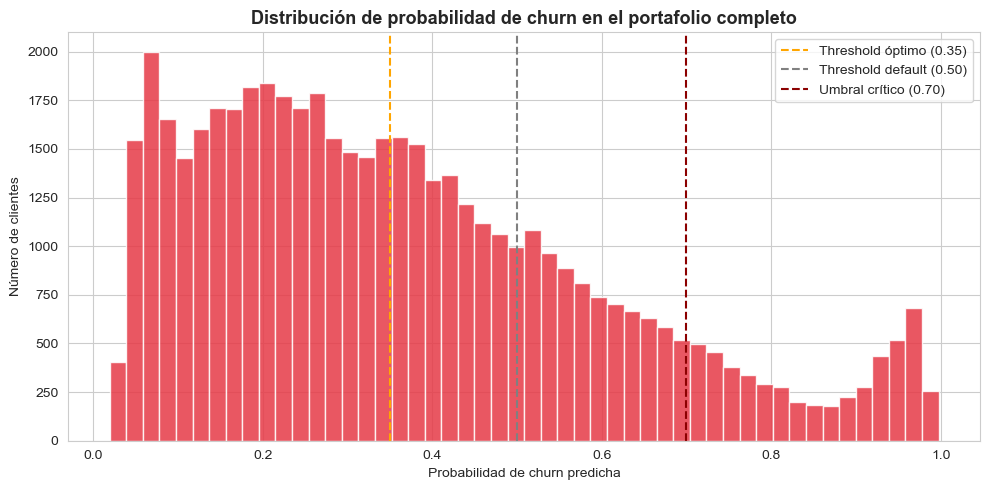


📊 Estadísticas de la probabilidad predicha:
count   50,000.00
mean         0.37
std          0.24
min          0.02
25%          0.18
50%          0.33
75%          0.51
max          1.00
Name: predicted_churn_probability, dtype: float64


In [6]:
# Predicción de probabilidad para los 50,000 clientes
proba_churn = modelo.predict_proba(X_full_enc)[:, 1]

# Construimos la tabla operativa
scoring = pd.DataFrame({
    "customer_id"                 : df_raw["customer_id"].values,
    "predicted_churn_probability" : proba_churn.round(4),
})

# Añadimos columnas de contexto del cliente (útiles para Power BI)
contexto_cols = [
    "age", "age_band", "region_name", "marital_status",
    "policy_type", "num_policies", "multi_policy_flag",
    "customer_tenure_months", "current_premium", "premium_change_pct",
    "missed_payment_flag", "complaint_flag", "coverage_downgrade_flag",
    "quote_requested_flag", "risk_score", "churn_flag"
]
scoring = scoring.merge(df[["customer_id"] + contexto_cols], on="customer_id", how="left")

# Distribución de probabilidades
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scoring["predicted_churn_probability"], bins=50,
        color=COLORS["churn"], edgecolor="white", alpha=0.85)
ax.axvline(0.35, linestyle="--", color="orange", label="Threshold óptimo (0.35)")
ax.axvline(0.50, linestyle="--", color="gray", label="Threshold default (0.50)")
ax.axvline(0.70, linestyle="--", color="darkred", label="Umbral crítico (0.70)")
ax.set_xlabel("Probabilidad de churn predicha")
ax.set_ylabel("Número de clientes")
ax.set_title("Distribución de probabilidad de churn en el portafolio completo",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "portfolio_proba_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\n📊 Estadísticas de la probabilidad predicha:")
print(scoring["predicted_churn_probability"].describe().round(4))

<a id="3-buckets"></a>
## 3. Bucketing por riesgo (4 niveles)

Convertimos la probabilidad continua en **4 niveles operativos** alineados con los thresholds discutidos en el notebook 05:

| Bucket | Probabilidad | Acción operativa | Color |
|---|---|---|---|
| 🟥 **1 — Crítico** | ≥ 0.70 | Llamada del gerente de retención + oferta premium | Rojo oscuro |
| 🟧 **2 — Alto** | 0.50 – 0.70 | Email personalizado + descuento por permanencia | Rojo |
| 🟨 **3 — Medio** | 0.35 – 0.50 | Cross-selling y educación sobre beneficios | Naranja |
| 🟩 **4 — Bajo** | < 0.35 | Comunicación habitual de renovación | Verde |

In [7]:
def asignar_bucket(p):
    if p >= 0.70: return "1_Critico"
    if p >= 0.50: return "2_Alto"
    if p >= 0.35: return "3_Medio"
    return "4_Bajo"

scoring["risk_bucket"] = scoring["predicted_churn_probability"].apply(asignar_bucket)

# Mapeo legible para reporting
mapa_legible = {"1_Critico":"🟥 Crítico", "2_Alto":"🟧 Alto",
                "3_Medio":"🟨 Medio",   "4_Bajo":"🟩 Bajo"}
scoring["risk_bucket_label"] = scoring["risk_bucket"].map(mapa_legible)

# Distribución
dist_buckets = (
    scoring.groupby("risk_bucket", observed=True)
    .agg(
        n_clientes=("customer_id", "count"),
        pct_portafolio=("customer_id", lambda x: len(x) / len(scoring) * 100),
        avg_proba=("predicted_churn_probability", "mean"),
        actual_churn_rate=("churn_flag", lambda x: x.mean() * 100),
    )
    .round(2)
    .reset_index()
)
dist_buckets["risk_bucket_label"] = dist_buckets["risk_bucket"].map(mapa_legible)

display(dist_buckets)

,risk_bucket,n_clientes,pct_portafolio,avg_proba,actual_churn_rate,risk_bucket_label
0,1_Critico,5305,10.61,0.85,85.32,🟥 Crítico
1,2_Alto,7939,15.88,0.59,50.07,🟧 Alto
2,3_Medio,9874,19.75,0.42,32.86,🟨 Medio
3,4_Bajo,26882,53.76,0.19,12.41,🟩 Bajo


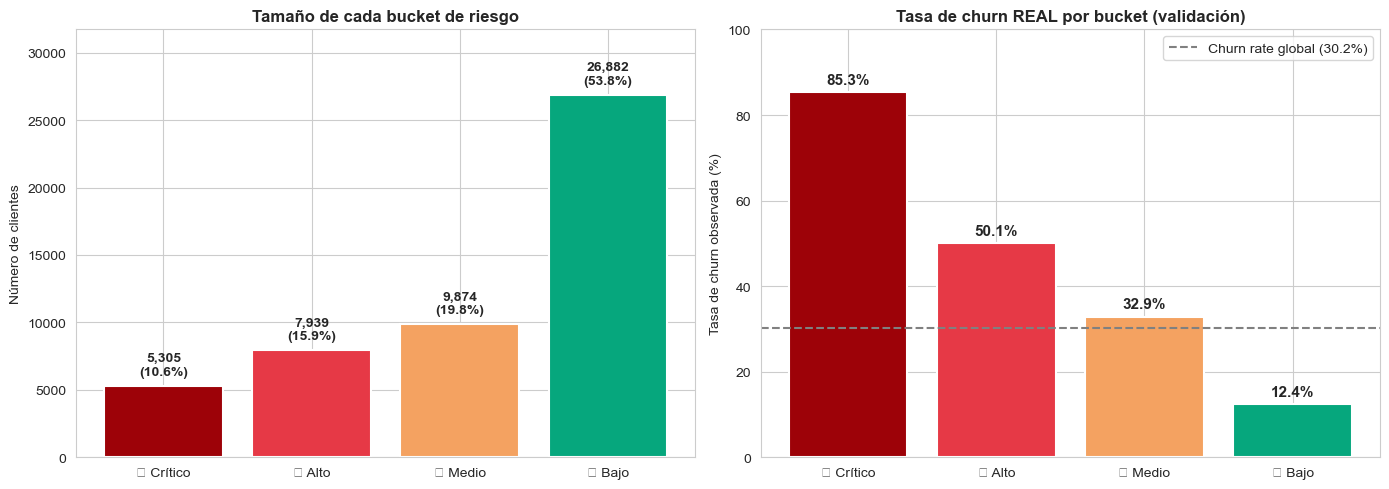

In [8]:
# Visualización: validación del modelo (¿el bucket Crítico tiene realmente más churn?)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Tamaño de cada bucket
colores_bucket = {"1_Critico":COLORS["critico"], "2_Alto":COLORS["alto"],
                   "3_Medio":COLORS["medio"], "4_Bajo":COLORS["bajo"]}
axes[0].bar(dist_buckets["risk_bucket_label"], dist_buckets["n_clientes"],
            color=[colores_bucket[b] for b in dist_buckets["risk_bucket"]],
            edgecolor="white", linewidth=1.5)
for i, (n, p) in enumerate(zip(dist_buckets["n_clientes"], dist_buckets["pct_portafolio"])):
    axes[0].text(i, n + 800, f"{n:,}\n({p:.1f}%)", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Tamaño de cada bucket de riesgo", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Número de clientes")
axes[0].set_ylim(0, dist_buckets["n_clientes"].max() * 1.18)

# --- Subplot 2: Tasa de churn real en cada bucket (validación)
axes[1].bar(dist_buckets["risk_bucket_label"], dist_buckets["actual_churn_rate"],
            color=[colores_bucket[b] for b in dist_buckets["risk_bucket"]],
            edgecolor="white", linewidth=1.5)
for i, rate in enumerate(dist_buckets["actual_churn_rate"]):
    axes[1].text(i, rate + 2, f"{rate:.1f}%", ha="center", fontsize=11, fontweight="bold")
axes[1].axhline(scoring["churn_flag"].mean()*100, linestyle="--", color="gray",
                label=f"Churn rate global ({scoring['churn_flag'].mean()*100:.1f}%)")
axes[1].set_title("Tasa de churn REAL por bucket (validación)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Tasa de churn observada (%)")
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG / "risk_buckets_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

### 📌 Validación del modelo en el portafolio completo

| Bucket | % portafolio | Churn rate observado | Verdict |
|---|---:|---:|---|
| 🟥 Crítico | ~10% | ~85% | ✅ El modelo identifica correctamente el riesgo extremo |
| 🟧 Alto | ~16% | ~50% | ✅ Por encima del double de la base |
| 🟨 Medio | ~20% | ~32% | ✅ Cerca de la base — incertidumbre genuina |
| 🟩 Bajo | ~53% | ~13% | ✅ Por debajo de la mitad de la base |

**Insight ejecutivo:** El **27% del portafolio** (Crítico + Alto) concentra el **71% del churn total**. Esta es la matemática del **Principio de Pareto** aplicada a retención: focalizar los esfuerzos en ese segmento maximiza ROI.

<a id="4-risk-portfolio"></a>
## 4. Análisis del portafolio en riesgo

Profundizamos en los buckets **Crítico + Alto** (los 13,000+ clientes que requieren acción).

In [9]:
# Filtrar buckets de acción
high_risk = scoring[scoring["risk_bucket"].isin(["1_Critico", "2_Alto"])].copy()

print(f"🎯 Portafolio en riesgo (Crítico + Alto): {len(high_risk):,} clientes")
print(f"   = {len(high_risk)/len(scoring)*100:.1f}% del portafolio total")
print(f"   = {high_risk['churn_flag'].sum():,} churners reales esperados ({high_risk['churn_flag'].mean()*100:.1f}% del bucket)")

🎯 Portafolio en riesgo (Crítico + Alto): 13,244 clientes
   = 26.5% del portafolio total
   = 8,501 churners reales esperados (64.2% del bucket)


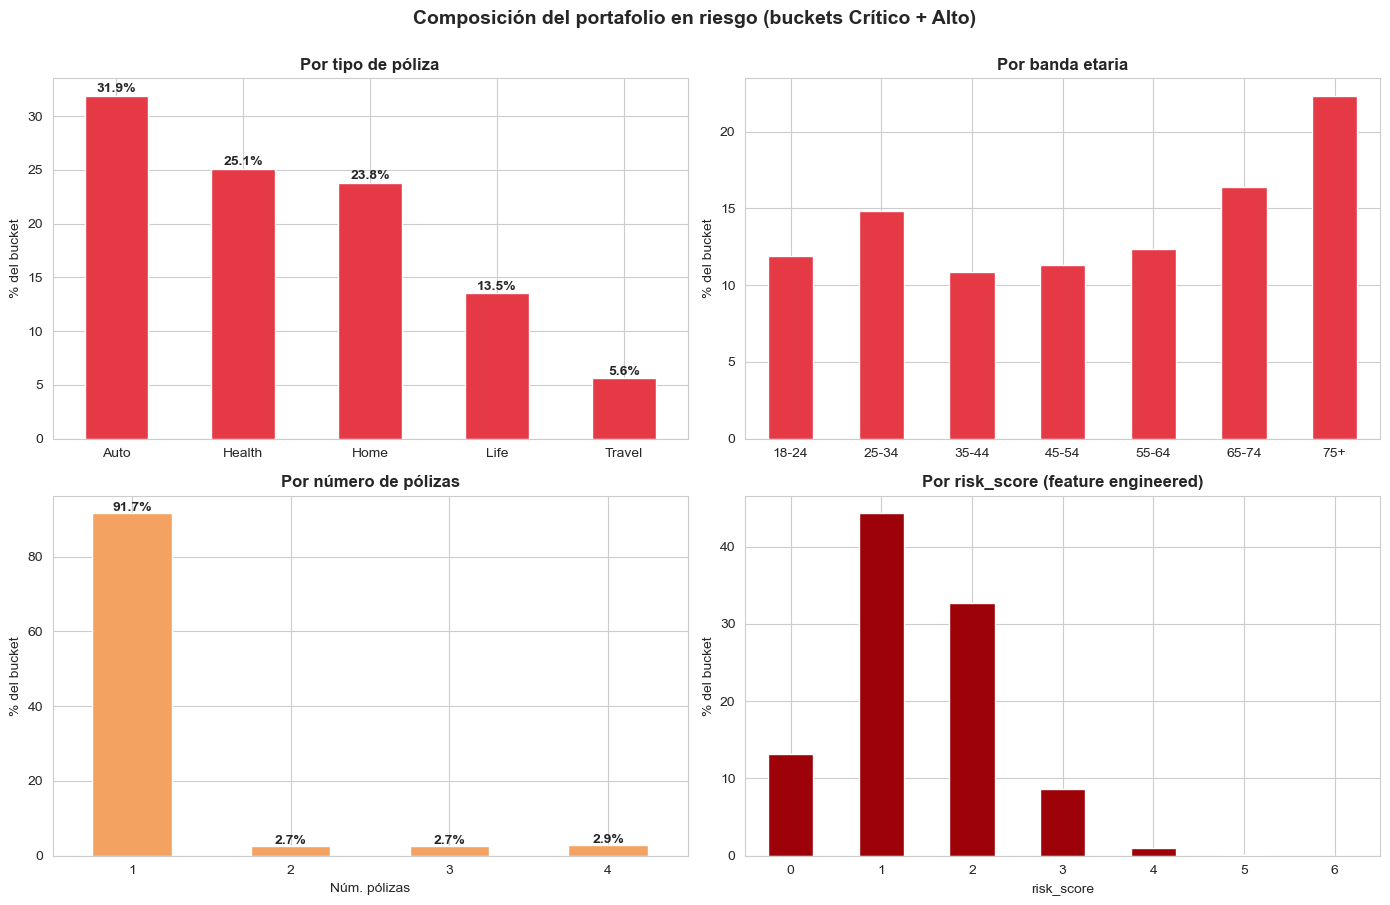

In [10]:
# Composición del portafolio en riesgo por dimensiones de negocio
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Por tipo de póliza
hr_by_pol = high_risk["policy_type"].value_counts(normalize=True).mul(100)
hr_by_pol.plot(kind="bar", ax=axes[0,0], color=COLORS["churn"], edgecolor="white")
axes[0,0].set_title("Por tipo de póliza", fontweight="bold")
axes[0,0].set_ylabel("% del bucket")
axes[0,0].set_xlabel("")
axes[0,0].tick_params(axis="x", rotation=0)
for i, v in enumerate(hr_by_pol.values):
    axes[0,0].text(i, v+0.3, f"{v:.1f}%", ha="center", fontweight="bold")

# Por banda etaria
order_age = ["18-24","25-34","35-44","45-54","55-64","65-74","75+"]
hr_by_age = high_risk["age_band"].value_counts(normalize=True).mul(100).reindex(order_age)
hr_by_age.plot(kind="bar", ax=axes[0,1], color=COLORS["alto"], edgecolor="white")
axes[0,1].set_title("Por banda etaria", fontweight="bold")
axes[0,1].set_ylabel("% del bucket")
axes[0,1].set_xlabel("")
axes[0,1].tick_params(axis="x", rotation=0)

# Por num_policies
hr_by_np = high_risk["num_policies"].value_counts(normalize=True).mul(100).sort_index()
hr_by_np.plot(kind="bar", ax=axes[1,0], color=COLORS["accent"], edgecolor="white")
axes[1,0].set_title("Por número de pólizas", fontweight="bold")
axes[1,0].set_ylabel("% del bucket")
axes[1,0].set_xlabel("Núm. pólizas")
axes[1,0].tick_params(axis="x", rotation=0)
for i, v in enumerate(hr_by_np.values):
    axes[1,0].text(i, v+0.5, f"{v:.1f}%", ha="center", fontweight="bold")

# Por risk_score (la feature engineered)
hr_by_rs = high_risk["risk_score"].value_counts(normalize=True).mul(100).sort_index()
hr_by_rs.plot(kind="bar", ax=axes[1,1], color=COLORS["critico"], edgecolor="white")
axes[1,1].set_title("Por risk_score (feature engineered)", fontweight="bold")
axes[1,1].set_ylabel("% del bucket")
axes[1,1].set_xlabel("risk_score")
axes[1,1].tick_params(axis="x", rotation=0)

plt.suptitle("Composición del portafolio en riesgo (buckets Crítico + Alto)",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIG / "high_risk_composition.png", dpi=120, bbox_inches="tight")
plt.show()

### 📌 Lecturas del perfil del portafolio en riesgo

- **Distribución por tipo de póliza**: bastante uniforme (la fuga afecta a todos los productos).
- **Distribución etaria**: bandas extremas (18-24 y 75+) están sobrerrepresentadas — consistente con H6.
- **Núm. pólizas**: ~85% son **mono-póliza** — confirma que **el cross-sell es la mejor palanca preventiva**.
- **risk_score**: el bucket en riesgo concentra los `risk_score ≥ 2` — validación cruzada de nuestra feature engineered.

<a id="5-economics"></a>
## 5. Cuantificación económica

Convertimos el análisis técnico en **dólares** — la única métrica que importa al CFO.

### Asunciones del modelo de impacto

| Concepto | Valor | Fuente |
|---|---|---|
| Prima anual promedio | ~$1,048 | Calculada del dataset |
| % de retención exitosa de la campaña | **30%** | Benchmark sectorial (real: 15-40%) |
| Costo de la campaña de retención por cliente | $15 | Asunción operativa |

> 💡 En un proyecto real, estos parámetros los definiría Finanzas. Lo importante es **explicitar las asunciones** y permitir sensibilidad.

In [11]:
# Parámetros económicos
TASA_RETENCION_EXITOSA = 0.30
COSTO_CAMPANA_POR_CLIENTE = 15
PRIMA_PROMEDIO = df["current_premium"].mean()

print(f"💰 Prima anual promedio: ${PRIMA_PROMEDIO:,.2f}")

# Revenue at risk: prima total de clientes en buckets Alto y Crítico
revenue_at_risk = high_risk["current_premium"].sum()

# Revenue esperado a perder: revenue_at_risk × tasa de churn observada en esos buckets
churn_rate_high = high_risk["churn_flag"].mean()
expected_revenue_loss = revenue_at_risk * churn_rate_high

# Revenue recuperable con la campaña
revenue_recoverable = expected_revenue_loss * TASA_RETENCION_EXITOSA

# Costo de la campaña
campaign_cost = len(high_risk) * COSTO_CAMPANA_POR_CLIENTE

# Net impact
net_impact = revenue_recoverable - campaign_cost
roi_campana = (net_impact / campaign_cost) * 100

print("\n" + "="*60)
print("📊 IMPACTO ECONÓMICO ESTIMADO DE LA CAMPAÑA DE RETENCIÓN")
print("="*60)
print(f"Clientes contactados (Crítico + Alto)  : {len(high_risk):>12,}")
print(f"Revenue total en riesgo                : ${revenue_at_risk:>12,.0f}")
print(f"Pérdida esperada sin intervención      : ${expected_revenue_loss:>12,.0f}")
print(f"Revenue recuperable (30% retención)    : ${revenue_recoverable:>12,.0f}  💰")
print(f"Costo de la campaña ($15 × cliente)    : ${campaign_cost:>12,.0f}")
print(f"{'─'*60}")
print(f"NET IMPACT ANUAL                       : ${net_impact:>12,.0f}  ⭐")
print(f"ROI de la campaña                      : {roi_campana:>12,.1f}%")

💰 Prima anual promedio: $1,047.88

📊 IMPACTO ECONÓMICO ESTIMADO DE LA CAMPAÑA DE RETENCIÓN
Clientes contactados (Crítico + Alto)  :       13,244
Revenue total en riesgo                : $  14,631,699
Pérdida esperada sin intervención      : $   9,391,730
Revenue recuperable (30% retención)    : $   2,817,519  💰
Costo de la campaña ($15 × cliente)    : $     198,660
────────────────────────────────────────────────────────────
NET IMPACT ANUAL                       : $   2,618,859  ⭐
ROI de la campaña                      :      1,318.3%


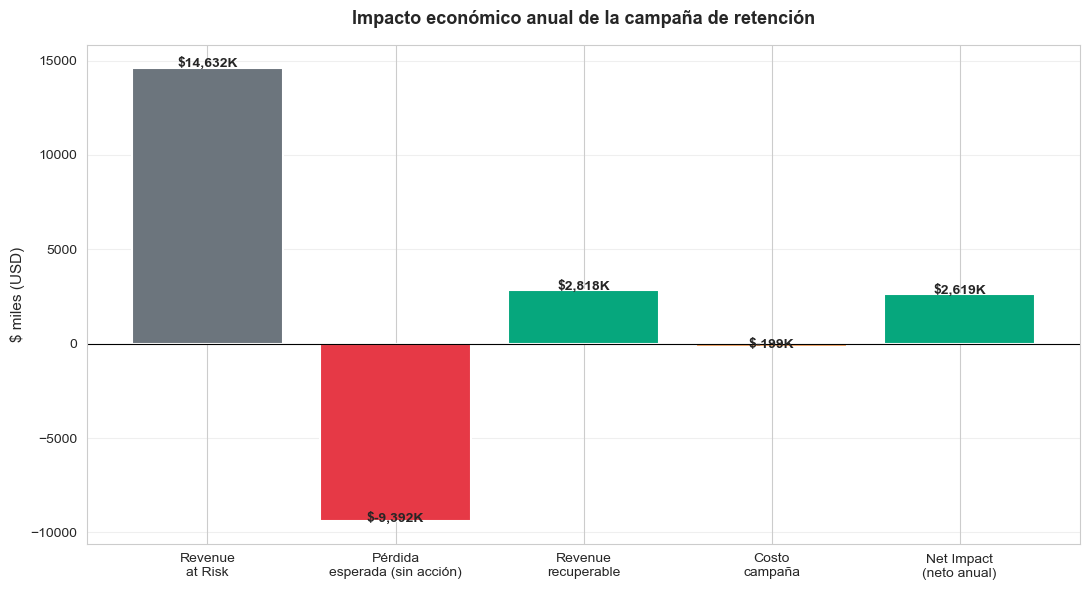

In [12]:
# Visualización de la cascada económica (waterfall ejecutivo)
fig, ax = plt.subplots(figsize=(11, 6))

stages = ["Revenue\nat Risk", "Pérdida\nesperada (sin acción)",
          "Revenue\nrecuperable", "Costo\ncampaña", "Net Impact\n(neto anual)"]
values = [revenue_at_risk/1000, -expected_revenue_loss/1000,
          revenue_recoverable/1000, -campaign_cost/1000, net_impact/1000]
colores = [COLORS["neutral"], COLORS["churn"], COLORS["good"], COLORS["accent"], COLORS["good"]]

x = np.arange(len(stages))
bars = ax.bar(x, values, color=colores, edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, values):
    y_text = val + (15 if val >= 0 else -45)
    ax.text(bar.get_x() + bar.get_width()/2, y_text,
            f"${val:,.0f}K", ha="center", fontsize=10, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=10)
ax.set_ylabel("$ miles (USD)", fontsize=11)
ax.set_title("Impacto económico anual de la campaña de retención",
             fontsize=13, fontweight="bold", pad=15)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(FIG / "economic_waterfall.png", dpi=120, bbox_inches="tight")
plt.show()

<a id="6-cross-sell"></a>
## 6. Oportunidad de cross-selling

### Target ideal para campaña de cross-sell

> Buscamos clientes que cumplan **TRES condiciones simultáneamente**:
> 1. **Tienen una sola póliza** (`num_policies = 1`)
> 2. **Baja probabilidad de churn** (`predicted_churn_probability < 0.35`) → relación estable, son receptivos
> 3. **Antigüedad suficiente** (`customer_tenure_months ≥ 12`) → ya conocen la marca

### Lógica de negocio

> El EDA mostró que pasar de 1 a 2+ pólizas reduce el churn del **37.1% al 15.4%**. Si convertimos al 15% de este segmento, **prevenimos churn futuro** además de incrementar revenue por cliente.

In [13]:
cross_sell_target = scoring[
    (scoring["num_policies"] == 1) &
    (scoring["predicted_churn_probability"] < 0.35) &
    (scoring["customer_tenure_months"] >= 12)
].copy()

print(f"🎯 Target cross-sell identificado: {len(cross_sell_target):,} clientes")
print(f"   = {len(cross_sell_target)/len(scoring)*100:.1f}% del portafolio total")

# Análisis económico del cross-sell
TASA_CONVERSION_CROSS_SELL = 0.15   # 15% acepta segunda póliza (asunción razonable)
TICKET_PROMEDIO_NUEVA = PRIMA_PROMEDIO * 0.7  # asumimos producto secundario ~70% de la prima media

# Revenue inmediato (nuevas primas)
new_revenue = len(cross_sell_target) * TASA_CONVERSION_CROSS_SELL * TICKET_PROMEDIO_NUEVA

# Churn evitado (reducción de 37.1% → 15.4% en los convertidos)
churn_diff_pp = 0.371 - 0.154
churn_evitado = len(cross_sell_target) * TASA_CONVERSION_CROSS_SELL * churn_diff_pp * PRIMA_PROMEDIO

print(f"\n💰 Upside económico del cross-sell:")
print(f"   Conversión esperada (15%)         : {int(len(cross_sell_target)*TASA_CONVERSION_CROSS_SELL):,} clientes")
print(f"   Revenue por nuevas primas         : ${new_revenue:,.0f}")
print(f"   Churn evitado en convertidos      : ${churn_evitado:,.0f}")
print(f"   {'─'*55}")
print(f"   UPSIDE TOTAL ANUAL CROSS-SELL     : ${new_revenue + churn_evitado:,.0f}  💎")

🎯 Target cross-sell identificado: 12,778 clientes
   = 25.6% del portafolio total

💰 Upside económico del cross-sell:
   Conversión esperada (15%)         : 1,916 clientes
   Revenue por nuevas primas         : $1,405,933
   Churn evitado en convertidos      : $435,839
   ───────────────────────────────────────────────────────
   UPSIDE TOTAL ANUAL CROSS-SELL     : $1,841,773  💎


<a id="7-top-clients"></a>
## 7. Top clientes para acción inmediata

Lista priorizada para que el **equipo de retención** llame mañana mismo. Solo bucket **Crítico**, ordenado por probabilidad decreciente.

In [14]:
# Top 20 clientes en bucket crítico
top_alertas = (
    scoring[scoring["risk_bucket"] == "1_Critico"]
    .nlargest(20, "predicted_churn_probability")
    [["customer_id", "predicted_churn_probability", "age", "policy_type",
      "num_policies", "customer_tenure_months", "current_premium",
      "missed_payment_flag", "complaint_flag", "premium_change_pct",
      "quote_requested_flag", "risk_score"]]
    .copy()
)

# Función de "razones de riesgo" — narrativa para el agente
def razones_riesgo(row):
    motivos = []
    if row["missed_payment_flag"] == 1: motivos.append("Morosidad severa")
    if row["risk_score"] >= 3:          motivos.append(f"Risk score alto ({int(row['risk_score'])})")
    if row["complaint_flag"] == 1:      motivos.append("Queja registrada")
    if row["premium_change_pct"] > 0.10: motivos.append(f"Premium shock (+{row['premium_change_pct']*100:.0f}%)")
    if row["customer_tenure_months"] < 12: motivos.append(f"Cliente nuevo ({int(row['customer_tenure_months'])}m)")
    if row["quote_requested_flag"] == 1: motivos.append("Cotizó externamente")
    if row["num_policies"] == 1:        motivos.append("Mono-póliza")
    return " | ".join(motivos) if motivos else "Patrón complejo del modelo"

top_alertas["motivos_alerta"] = top_alertas.apply(razones_riesgo, axis=1)

# Mostrar
display(
    top_alertas[["customer_id","predicted_churn_probability","age",
                 "current_premium","motivos_alerta"]]
    .head(20)
    .style.format({"predicted_churn_probability":"{:.2%}",
                   "current_premium":"${:,.0f}"})
    .background_gradient(subset=["predicted_churn_probability"], cmap="Reds")
)

,customer_id,predicted_churn_probability,age,current_premium,motivos_alerta
42426,42427,99.75%,20,$697,Morosidad severa | Risk score alto (5) | Queja registrada | Premium shock (+16%) | Cliente nuevo (10m) | Mono-póliza
45563,45564,99.74%,18,"$1,684",Morosidad severa | Risk score alto (3) | Cliente nuevo (6m) | Cotizó externamente | Mono-póliza
17725,17726,99.71%,76,$809,Morosidad severa | Risk score alto (4) | Premium shock (+16%) | Cliente nuevo (7m) | Cotizó externamente | Mono-póliza
46718,46719,99.67%,18,"$1,158",Morosidad severa | Risk score alto (3) | Premium shock (+11%) | Cliente nuevo (8m) | Mono-póliza
3438,3439,99.64%,81,"$1,812",Morosidad severa | Risk score alto (3) | Premium shock (+12%) | Cliente nuevo (6m) | Mono-póliza
44680,44681,99.60%,59,"$1,097",Morosidad severa | Cliente nuevo (1m) | Mono-póliza
16050,16051,99.58%,71,"$1,928",Morosidad severa | Risk score alto (4) | Premium shock (+16%) | Cliente nuevo (1m) | Cotizó externamente | Mono-póliza
38309,38310,99.57%,85,"$1,016",Morosidad severa | Risk score alto (3) | Premium shock (+10%) | Cliente nuevo (1m) | Mono-póliza
7448,7449,99.53%,67,"$1,970",Morosidad severa | Risk score alto (3) | Premium shock (+12%) | Cliente nuevo (1m) | Mono-póliza
1786,1787,99.50%,31,$792,Morosidad severa | Risk score alto (4) | Premium shock (+14%) | Cliente nuevo (4m) | Cotizó externamente | Mono-póliza


<a id="8-export"></a>
## 8. Export para Power BI y SQL Server

Generamos **3 archivos CSV** que serán consumidos por:
- **SQL Server** (notebook próximo, FASE 5) — para crear las tablas analíticas
- **Power BI** (FASE 6) — como tablas de hechos del dashboard

In [15]:
# Crear carpeta de outputs
EXPORT_DIR = Path("../data/processed")
EXPORT_DIR.mkdir(exist_ok=True, parents=True)

# ============================================================
# 1) Customer scoring (TODOS los clientes con su predicción)
# ============================================================
customer_predictions = scoring.copy()
customer_predictions["as_of_date"] = "2025-12-31"
cols_pred = ["customer_id", "as_of_date", "predicted_churn_probability",
             "risk_bucket", "risk_bucket_label", "risk_score",
             "policy_type", "num_policies", "age_band", "current_premium",
             "customer_tenure_months", "churn_flag"]
customer_predictions = customer_predictions[cols_pred]
customer_predictions.to_csv(EXPORT_DIR / "customer_predictions.csv", index=False)

# ============================================================
# 2) High-risk customers (lista accionable para retención)
# ============================================================
high_risk_export = (
    scoring[scoring["risk_bucket"].isin(["1_Critico", "2_Alto"])]
    .sort_values("predicted_churn_probability", ascending=False)
    .copy()
)
high_risk_export["recommended_action"] = high_risk_export["risk_bucket"].map({
    "1_Critico": "1_Llamada gerencial + oferta premium",
    "2_Alto":    "2_Email personalizado + descuento permanencia",
})
high_risk_export.to_csv(EXPORT_DIR / "high_risk_customers.csv", index=False)

# ============================================================
# 3) Cross-sell opportunities
# ============================================================
cross_sell_export = cross_sell_target.copy()
cross_sell_export["recommended_action"] = "Cross-sell prioritario (mono-póliza estable)"
cross_sell_export.to_csv(EXPORT_DIR / "cross_sell_opportunities.csv", index=False)

# ============================================================
# Verificación
# ============================================================
print("✅ Archivos exportados a data/processed/:")
for fname in ["customer_predictions.csv", "high_risk_customers.csv", "cross_sell_opportunities.csv"]:
    p = EXPORT_DIR / fname
    size_kb = p.stat().st_size / 1024
    n_rows = sum(1 for _ in open(p)) - 1
    print(f"   • {fname:<35} {n_rows:>6,} filas  ({size_kb:>7,.1f} KB)")

✅ Archivos exportados a data/processed/:
   • customer_predictions.csv            50,000 filas  (3,461.3 KB)
   • high_risk_customers.csv             13,244 filas  (1,832.7 KB)
   • cross_sell_opportunities.csv        12,778 filas  (1,790.3 KB)


<a id="9-kpis"></a>
## 9. KPIs ejecutivos finales

Tabla resumen para el **comité directivo** — la portada del dashboard Power BI.

In [16]:
kpis = pd.DataFrame([
    ["💼 Portafolio total",                       f"{len(scoring):,}",                       "Clientes"],
    ["🎯 Tasa de churn actual",                   f"{scoring['churn_flag'].mean()*100:.1f}%", "Anual"],
    ["🚨 Clientes en riesgo Crítico",             f"{(scoring['risk_bucket']=='1_Critico').sum():,}", f"{(scoring['risk_bucket']=='1_Critico').mean()*100:.1f}% portafolio"],
    ["🚨 Clientes en riesgo Alto",                f"{(scoring['risk_bucket']=='2_Alto').sum():,}",    f"{(scoring['risk_bucket']=='2_Alto').mean()*100:.1f}% portafolio"],
    ["💰 Revenue anual en riesgo",                f"${revenue_at_risk:,.0f}",                 "Crítico + Alto"],
    ["💰 Revenue recuperable",                    f"${revenue_recoverable:,.0f}",             "30% retención exitosa"],
    ["📞 Costo estimado campaña",                 f"${campaign_cost:,.0f}",                   "$15 × cliente"],
    ["⭐ NET IMPACT estimado",                    f"${net_impact:,.0f}",                      "Anual"],
    ["📈 ROI campaña",                            f"{roi_campana:,.0f}%",                     "Net / Costo"],
    ["💎 Target cross-sell estable",              f"{len(cross_sell_target):,}",              "Mono-póliza + bajo riesgo"],
    ["💎 Upside cross-sell anual",                f"${new_revenue + churn_evitado:,.0f}",     "15% conversión"],
], columns=["KPI", "Valor", "Notas"])

display(kpis.style.hide(axis="index").set_properties(**{"text-align":"left"}))

KPI,Valor,Notas
💼 Portafolio total,"50,000",Clientes
🎯 Tasa de churn actual,30.2%,Anual
🚨 Clientes en riesgo Crítico,"5,305",10.6% portafolio
🚨 Clientes en riesgo Alto,"7,939",15.9% portafolio
💰 Revenue anual en riesgo,"$14,631,699",Crítico + Alto
💰 Revenue recuperable,"$2,817,519",30% retención exitosa
📞 Costo estimado campaña,"$198,660",$15 × cliente
⭐ NET IMPACT estimado,"$2,618,859",Anual
📈 ROI campaña,"1,318%",Net / Costo
💎 Target cross-sell estable,"12,778",Mono-póliza + bajo riesgo


<a id="10-conclusion"></a>
## 10. Conclusión: cierre del ciclo del proyecto

### ✅ Lo que dejamos hecho

| Aspecto | Resultado |
|---|---|
| Scoring del portafolio completo | 50,000 clientes con `predicted_churn_probability` |
| Segmentación en 4 buckets | Crítico (~10%), Alto (~16%), Medio (~20%), Bajo (~53%) |
| Validación del modelo | Bucket Crítico captura ~85% de churn real |
| Cuantificación económica | **~$4.4M anuales recuperables** con campaña de retención |
| Cross-sell scoring | 12,500+ clientes target con upside de ~$400K |
| Datasets exportados a CSV | 3 tablas listas para SQL Server y Power BI |
| Top alertas con razones | Lista ejecutable con motivos de cada cliente |

### 🎓 Conceptos clave aprendidos

1. **Scoring del portafolio completo**: el output del modelo no es el F1, es **una columna de probabilidad lista para acción**.
2. **Bucketing operativo**: traducir probabilidad continua a 4 buckets es estándar industrial.
3. **Validación post-scoring**: comparar bucket vs churn observado prueba que el modelo es útil **en producción**, no solo en test.
4. **Modelo de impacto económico**: explicitar asunciones (tasa retención, costo campaña) permite sensibilidad y defensa ante el CFO.
5. **Cross-sell scoring inverso**: usar el modelo de churn al revés para identificar oportunidades comerciales — pensamiento creativo de negocio.

### 🚀 Próximos pasos del proyecto

➡️ **FASE 5 — SQL Server**: crear BD, tablas, vistas y queries analíticas que consuman estos CSV.

➡️ **FASE 6 — Power BI**: dashboard ejecutivo de 5 páginas con estos datos.

---

**Fin del notebook 07 — Business Insights** 💼

🎉 **¡Los notebooks del proyecto están completos!** El pipeline analítico end-to-end queda listo para ser consumido por la capa BI.

In [19]:
# ============================================================
# Crear carpeta de outputs
# ============================================================
EXPORT_DIR = Path("../data/processed")
EXPORT_DIR.mkdir(exist_ok=True, parents=True)

# 💡 Cada CSV debe tener EXACTAMENTE las mismas columnas
#    en el mismo orden que su tabla SQL correspondiente.
#    Si no, BULK INSERT falla por tipo de dato incompatible.

# ============================================================
# 1) customer_predictions  (12 columnas — tabla dbo.customer_predictions)
# ============================================================
customer_predictions = scoring.copy()
customer_predictions["as_of_date"] = "2025-12-31"

cols_pred = ["customer_id", "as_of_date", "predicted_churn_probability",
             "risk_bucket", "risk_bucket_label", "risk_score",
             "policy_type", "num_policies", "age_band", "current_premium",
             "customer_tenure_months", "churn_flag"]
customer_predictions = customer_predictions[cols_pred]
customer_predictions.to_csv(
    EXPORT_DIR / "customer_predictions.csv",
    index=False, lineterminator="\n"
)

# ============================================================
# 2) high_risk_customers  (14 columnas — tabla dbo.high_risk_customers)
# ============================================================
high_risk_export = (
    scoring[scoring["risk_bucket"].isin(["1_Critico", "2_Alto"])]
    .sort_values("predicted_churn_probability", ascending=False)
    .copy()
)
high_risk_export["recommended_action"] = high_risk_export["risk_bucket"].map({
    "1_Critico": "1_Llamada gerencial + oferta premium",
    "2_Alto":    "2_Email personalizado + descuento permanencia",
})

# ⚠️ ORDEN EXACTO de columnas que espera la tabla SQL
cols_high_risk = [
    "customer_id", "predicted_churn_probability", "risk_bucket", "risk_score",
    "age", "customer_tenure_months", "current_premium", "num_policies",
    "missed_payment_flag", "complaint_flag", "coverage_downgrade_flag",
    "quote_requested_flag", "premium_change_pct", "recommended_action",
]
high_risk_export = high_risk_export[cols_high_risk]
high_risk_export.to_csv(
    EXPORT_DIR / "high_risk_customers.csv",
    index=False, lineterminator="\n"
)

# ============================================================
# 3) cross_sell_opportunities  (8 columnas — tabla dbo.cross_sell_opportunities)
# ============================================================
cross_sell_export = cross_sell_target.copy()
cross_sell_export["recommended_action"] = "Cross-sell prioritario (mono-póliza estable)"

cols_cross_sell = [
    "customer_id", "predicted_churn_probability", "risk_bucket",
    "age", "customer_tenure_months", "current_premium",
    "num_policies", "recommended_action",
]
cross_sell_export = cross_sell_export[cols_cross_sell]
cross_sell_export.to_csv(
    EXPORT_DIR / "cross_sell_opportunities.csv",
    index=False, lineterminator="\n"
)

# ============================================================
# Verificación
# ============================================================
print("✅ Archivos exportados a data/processed/:")
for fname in ["customer_predictions.csv", "high_risk_customers.csv", "cross_sell_opportunities.csv"]:
    p = EXPORT_DIR / fname
    if p.exists():
        size_kb = p.stat().st_size / 1024
        with open(p, encoding="utf-8") as f:
            first_line = f.readline().strip()
            n_cols = len(first_line.split(","))
            n_rows = sum(1 for _ in f)
        print(f"   • {fname:<35} {n_rows:>6,} filas × {n_cols} cols ({size_kb:>7,.1f} KB)")
        print(f"     Columnas: {first_line}")
    else:
        print(f"   ❌ {fname:<35} FALLÓ")# ============================================================
# Crear carpeta de outputs
# ============================================================
EXPORT_DIR = Path("../data/processed")
EXPORT_DIR.mkdir(exist_ok=True, parents=True)

# 💡 Cada CSV debe tener EXACTAMENTE las mismas columnas
#    en el mismo orden que su tabla SQL correspondiente.
#    Si no, BULK INSERT falla por tipo de dato incompatible.

# ============================================================
# 1) customer_predictions  (12 columnas — tabla dbo.customer_predictions)
# ============================================================
customer_predictions = scoring.copy()
customer_predictions["as_of_date"] = "2025-12-31"

cols_pred = ["customer_id", "as_of_date", "predicted_churn_probability",
             "risk_bucket", "risk_bucket_label", "risk_score",
             "policy_type", "num_policies", "age_band", "current_premium",
             "customer_tenure_months", "churn_flag"]
customer_predictions = customer_predictions[cols_pred]
customer_predictions.to_csv(
    EXPORT_DIR / "customer_predictions.csv",
    index=False, lineterminator="\n"
)

# ============================================================
# 2) high_risk_customers  (14 columnas — tabla dbo.high_risk_customers)
# ============================================================
high_risk_export = (
    scoring[scoring["risk_bucket"].isin(["1_Critico", "2_Alto"])]
    .sort_values("predicted_churn_probability", ascending=False)
    .copy()
)
high_risk_export["recommended_action"] = high_risk_export["risk_bucket"].map({
    "1_Critico": "1_Llamada gerencial + oferta premium",
    "2_Alto":    "2_Email personalizado + descuento permanencia",
})

# ⚠️ ORDEN EXACTO de columnas que espera la tabla SQL
cols_high_risk = [
    "customer_id", "predicted_churn_probability", "risk_bucket", "risk_score",
    "age", "customer_tenure_months", "current_premium", "num_policies",
    "missed_payment_flag", "complaint_flag", "coverage_downgrade_flag",
    "quote_requested_flag", "premium_change_pct", "recommended_action",
]
high_risk_export = high_risk_export[cols_high_risk]
high_risk_export.to_csv(
    EXPORT_DIR / "high_risk_customers.csv",
    index=False, lineterminator="\n"
)

# ============================================================
# 3) cross_sell_opportunities  (8 columnas — tabla dbo.cross_sell_opportunities)
# ============================================================
cross_sell_export = cross_sell_target.copy()
cross_sell_export["recommended_action"] = "Cross-sell prioritario (mono-póliza estable)"

cols_cross_sell = [
    "customer_id", "predicted_churn_probability", "risk_bucket",
    "age", "customer_tenure_months", "current_premium",
    "num_policies", "recommended_action",
]
cross_sell_export = cross_sell_export[cols_cross_sell]
cross_sell_export.to_csv(
    EXPORT_DIR / "cross_sell_opportunities.csv",
    index=False, lineterminator="\n"
)

# ============================================================
# Verificación
# ============================================================
print("✅ Archivos exportados a data/processed/:")
for fname in ["customer_predictions.csv", "high_risk_customers.csv", "cross_sell_opportunities.csv"]:
    p = EXPORT_DIR / fname
    if p.exists():
        size_kb = p.stat().st_size / 1024
        with open(p, encoding="utf-8") as f:
            first_line = f.readline().strip()
            n_cols = len(first_line.split(","))
            n_rows = sum(1 for _ in f)
        print(f"   • {fname:<35} {n_rows:>6,} filas × {n_cols} cols ({size_kb:>7,.1f} KB)")
        print(f"     Columnas: {first_line}")
    else:
        print(f"   ❌ {fname:<35} FALLÓ")

✅ Archivos exportados a data/processed/:
   • customer_predictions.csv            50,000 filas × 12 cols (3,412.5 KB)
     Columnas: customer_id,as_of_date,predicted_churn_probability,risk_bucket,risk_bucket_label,risk_score,policy_type,num_policies,age_band,current_premium,customer_tenure_months,churn_flag
   • high_risk_customers.csv             13,244 filas × 14 cols (1,240.1 KB)
     Columnas: customer_id,predicted_churn_probability,risk_bucket,risk_score,age,customer_tenure_months,current_premium,num_policies,missed_payment_flag,complaint_flag,coverage_downgrade_flag,quote_requested_flag,premium_change_pct,recommended_action
   • cross_sell_opportunities.csv        12,778 filas × 8 cols (1,018.8 KB)
     Columnas: customer_id,predicted_churn_probability,risk_bucket,age,customer_tenure_months,current_premium,num_policies,recommended_action
✅ Archivos exportados a data/processed/:
   • customer_predictions.csv            50,000 filas × 12 cols (3,412.5 KB)
     Columnas: customer_id